# Практика. Тензорное исчисление и автоматическое дифференцирование
---

## Цели работы
1. Научиться создавать и преобразовывать тензоры в PyTorch.
2. Понять механизм broadcasting и выполнять базовые линейно-алгебраические операции.
3. Вычислить градиент простой функции аналитически и сравнить с результатом `autograd`.
4. Исследовать вычислительный граф на примере более сложной функции.

---

## Повторение (на пальцах 🖐️)

- **Тензор** — это просто многомерный массив. Скаляр (0D), вектор (1D), матрица (2D), кубик (3D) и дальше — сколько угодно измерений.
- **Broadcasting** — умное растягивание меньшего тензора под размер большего при выполнении операций (как когда вы на вечеринке растягиваете историю, чтобы её слушали все).
- **Градиент** — вектор частных производных. Показывает направление наискорейшего роста функции. В машинном обучении мы идём **против** градиента, чтобы уменьшить ошибку.
- **Autograd** — встроенный в PyTorch механизм автоматического дифференцирования. Он строит вычислительный граф и по команде `.backward()` раскручивает его в обратную сторону, заполняя градиенты.

Всё вспомнили? Поехали!

## Задание 1. Основы тензорных операций

**Цель:** освоиться с созданием, индексацией, broadcasting и линейной алгеброй в PyTorch.

Импортируйте PyTorch (и NumPy, если потребуется) и выполните следующие пункты. Пишите код в ячейках ниже.

1. Создайте:
   - скаляр со значением 3.14;
   - вектор из чисел от 0 до 99;
   - матрицу 3×3, заполненную единицами;
   - тензор размера 2×3×4, заполненный случайными числами из стандартного нормального распределения (используйте `torch.randn`).
2. Создайте две случайные матрицы 5×5 и сложите их поэлементно.
3. Создайте матрицу 3×4 и вектор длины 4. Выполните матричное умножение (используйте `@` или `torch.mm`). Что получилось? Какой размер у результата?
4. Создайте вектор `v = torch.tensor([1, 2, 3])` и матрицу `m = torch.tensor([[[10, 20, 30], [40, 50, 60]],[[10, 20, 30], [40, 50, 60]]])`. Сложите их (`v + m`). Объясните, как сработал broadcasting.
5. Создайте тензор формы (1, 24). Измените его форму на (3, 8) с помощью `.view()`. Что произойдёт, если вы попытаетесь изменить на (2, 13)? Проверьте и зафиксируйте ошибку.

*Подсказка:* размерности можно проверять через `.shape`.

**Выводы по заданию 1:** (напишите в Markdown-ячейке после кода)

In [15]:
# Ваш код для задания 1
import torch

# 1. Создание тензоров
scalar = torch.scalar_tensor(3.14, dtype=torch.float32)
vector = torch.linspace(1, 99, 1)
matrix_ones = torch.full((3, 3), 1)
tensor_randn = torch.randn((2, 3, 4))

# 2. Случайные матрицы и сложение
A = torch.randn(5,5)
B = torch.randn(5,5)
C = A + B

# 3. Матричное умножение
M = torch.randn(3,4)
V = torch.randn(4,1)
result = torch.mm(M, V)
print(result.shape)

# 4. Broadcasting
v = torch.tensor([1,2,3])
m = torch.tensor([
    [[10, 20, 30], [40, 50, 60]],
    [[10, 20, 30], [40, 50, 60]],
    ])
sum_bc = v + m
print(m.shape, v.shape, sum_bc)

# 5. Изменение формы
x = torch.randn(1,24)
x_reshaped = x.view(3, 8)
print(x_reshaped.shape)
# Попробуйте x.view(2,13)
print(x.view(2, 13).shape)

torch.Size([3, 1])
torch.Size([2, 2, 3]) torch.Size([3]) tensor([[[11, 22, 33],
         [41, 52, 63]],

        [[11, 22, 33],
         [41, 52, 63]]])
torch.Size([3, 8])


RuntimeError: shape '[2, 13]' is invalid for input of size 24

### Место для выводов по заданию 1
(опишите, что получилось, были ли ошибки, как работает broadcasting и т.д.)
<br>3. Вектор размера 3
<br>4. Broadcasting сначала дополнил одномерный тензор единиицами справа до [1, 1, 3], потом проверил справа на лево измерения, 3 и 3 совпали, 1 можно растянуть до 2, и 1 можно растянуть до 2 потом вектор прибавлися к каждой строке строке в тензоре m
<br>5. Количество элементов в изначальном тензоре не совпало с кольчество элементов во view с размером (2, 13)

## Задание 2. Ручной расчёт градиента и проверка autograd

**Цель:** убедиться, что autograd не врёт, и заодно вспомнить частные производные.

Рассмотрим функцию двух переменных (сразу смотрите функцию из бонусного варианта):
$$
f(x, y) = x^2 y + y^3
$$

1. Аналитически найдите частные производные и вычислите градиент в точке $x = 2, y = 3$. Запишите ответы (можно прямо в Markdown).
2. Создайте тензоры `x` и `y` с `requires_grad=True`, инициализировав их значениями 2 и 3.
3. Вычислите `f` и вызовите `backward()`.
4. Распечатайте `x.grad` и `y.grad`. Сравните с аналитическим расчётом.
5. **Бонус:** измените функцию, например, добавьте синус: $f = x^2 y + \sin(y)$. Повторите вычисления аналитически и через autograd.

*Подсказка:* аналитически: $\partial f/\partial x = 2xy$, $\partial f/\partial y = x^2 + 3y^2$. При (2,3): (12, 4+27=31).

In [16]:
# Ваш код для задания 2
x = torch.tensor(2.0, requires_grad=True)
y = torch.tensor(3.0, requires_grad=True)

f = x**2*y + y**3
f.backward()

print("Градиент по x:", x.grad)
print("Градиент по y:", y.grad)

Градиент по x: tensor(12.)
Градиент по y: tensor(31.)


### Выводы по заданию 2
Совпали, понятен

## Задание 3. Исследование вычислительного графа

**Цель:** научиться отслеживать промежуточные узлы графа и понимать, откуда берутся градиенты.

Дана функция:
$$
L = (\mathbf{a} \cdot \mathbf{b} + c)^2
$$
где $\mathbf{a}, \mathbf{b}$ — векторы длины 3, $c$ — скаляр, а $\cdot$ — скалярное произведение (можно использовать `torch.dot`).

1. Задайте конкретные значения: `a = torch.tensor([1., 2., 3.], requires_grad=True)`, `b = torch.tensor([4., 5., 6.], requires_grad=True)`, `c = torch.tensor([7.], requires_grad=True)`.
2. Вычислите `L`.
3. Вызовите `backward()` и выведите градиенты по `a`, `b`, `c`.
4. Попробуйте объяснить, почему градиент по `a` именно такой. Для этого можно:
   - Вспомнить, что скалярное произведение — это сумма поэлементных произведений.
   - Записать формулу явно и взять производную по каждому компоненту.
5. (Бонус) Выведите значение промежуточного узла: `s = torch.dot(a, b) + c` и его градиент (можно получить, если сохранить его и вызвать ` s.retain_grad()  s.backward()`, но аккуратно с повторным вызовом).

**Важно:** перед повторным вызовом backward нужно обнулить градиенты, иначе они накопятся. Используйте `.zero_()`.

In [34]:
# Ваш код для задания 3
a = torch.tensor([1.,2.,3.], requires_grad=True)
b = torch.tensor([4., 5., 6.], requires_grad=True)
c = torch.tensor([7.], requires_grad=True)

s = torch.dot(a, b) + c
L = s ** 2
L.backward()

print("grad a:", a.grad)
print("grad b:", b.grad)
print("grad c:", c.grad)


# a.grad = (dl/ds)*(ds/da) 
print("a.grad = ", 2*s*b)

# b.grad = (dl/ds)*(ds/db) 
print("b.grad = ", 2*s*a)

# c.grad = (dl/ds)*(ds/dc) 
print("c.grad = ", 2*s*1)


# Бонус: получите градиент для s (сначала обнулите, если нужно)
a.grad.zero_(); b.grad.zero_(); c.grad.zero_()
s = torch.dot(a,b) + c
s.retain_grad()
L = s**2

L.backward()
print("s.grad = ", s.grad)

grad a: tensor([312., 390., 468.])
grad b: tensor([ 78., 156., 234.])
grad c: tensor([78.])
a.grad =  tensor([312., 390., 468.], grad_fn=<MulBackward0>)
b.grad =  tensor([ 78., 156., 234.], grad_fn=<MulBackward0>)
c.grad =  tensor([78.], grad_fn=<MulBackward0>)
s.grad =  tensor([78.])


### Выводы по заданию 3
(опишите связь между градиентами и структурой функции)

Для получения градиента a мы прсто вычисляем dL/da по цепному правилу = (dl/ds)*(ds/da)

## Задание 4. Линейная регрессия с autograd

**Цель:** применить autograd для обучения простой модели.

Сгенерируйте данные:
$$y_{\text{true}} = -5 x + 12 + \text{шум}$$
для 200 точек x от -10 до 10.

Инициализируйте случайные параметры `w` и `b` с `requires_grad=True`. Напишите цикл обучения на 100 эпох:
- оценка целевой функции `y_pred = w * x + b`;
- функция потерь: RMSE (`((y_pred - y_true)**2).mean()`) (добавить корень);
- `loss.backward()`;
- обновление весов вручную (без оптимизатора): `w.data -= lr * w.grad`, `b.data -= lr * b.grad` (используйте `.data` или блок `torch.no_grad()`);
- обнуление градиентов.

Выведите итоговые параметры и постройте
1. График изменения loss с увеличением эпох;
2. Линейные графики исходной и полученной функций;
3. График самой функции loss и движение поиска минимума по ней.

*Подсказка:* не забудьте обнулять градиенты после каждого шага.

Это задание повторяет пример из лекции — попробуйте выполнить его без подглядывания, а потом сверьтесь.

True
tensor(84.1228, grad_fn=<MseLossBackward0>) tensor(84.1228, grad_fn=<MeanBackward0>)
tensor([-103.6475])
tensor([-15.1804])
True
tensor(11.9769, grad_fn=<MseLossBackward0>) tensor(11.9769, grad_fn=<MeanBackward0>)
tensor([-32.6822])
tensor([-4.5120])
True
tensor(4.8200, grad_fn=<MseLossBackward0>) tensor(4.8200, grad_fn=<MeanBackward0>)
tensor([-10.3328])
tensor([-1.1536])
True
tensor(4.1088, grad_fn=<MseLossBackward0>) tensor(4.1088, grad_fn=<MeanBackward0>)
tensor([-3.2941])
tensor([-0.0972])
True
tensor(4.0368, grad_fn=<MseLossBackward0>) tensor(4.0368, grad_fn=<MeanBackward0>)
tensor([-1.0772])
tensor([0.2341])
True
tensor(4.0283, grad_fn=<MseLossBackward0>) tensor(4.0283, grad_fn=<MeanBackward0>)
tensor([-0.3789])
tensor([0.3372])
True
tensor(4.0261, grad_fn=<MseLossBackward0>) tensor(4.0261, grad_fn=<MeanBackward0>)
tensor([-0.1587])
tensor([0.3683])
True
tensor(4.0246, grad_fn=<MseLossBackward0>) tensor(4.0246, grad_fn=<MeanBackward0>)
tensor([-0.0892])
tensor([0.3768])
Tru

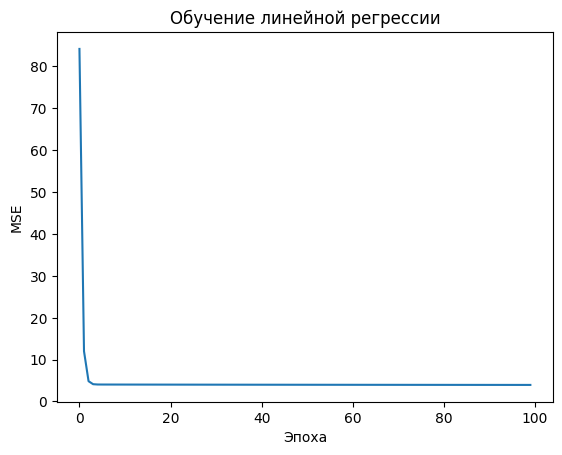

In [ ]:
# Ваш код для задания 4
import matplotlib.pyplot as plt

# Генерация данных
x_true = torch.linspace(0, 10, 100)
y_true = 2.5 * x_true + 1.3 + torch.randn_like(x_true) * 2.0

# Инициализация параметров
w = torch.randn(1, requires_grad=True)
b = torch.randn(1, requires_grad=True)

lr = 0.01
loss_history = []
loss_func = torch.nn.MSELoss()

for epoch in range(100):
    # Прямой проход
    y_pred = w*x_true + b

    loss = ((y_pred - y_true)**2).mean()

    loss_mse = loss_func(y_pred, y_true)
    print(torch.allclose(loss, loss_mse))
    print(loss_mse, loss)
    loss_history.append(loss.item())

    # Обратный проход
    loss_mse.backward()

    # Обновление весов
    with torch.no_grad():
        w -= w.grad * 0.01
        b -= b.grad * 0.01
    print(w.grad)
    print(b.grad)

    # Обнуление градиентов
    w.grad.zero_()
    b.grad.zero_()

print(f"Результат: w = {w.item():.3f}, b = {b.item():.3f}")

plt.plot(loss_history)
plt.xlabel("Эпоха")
plt.ylabel("MSE")
plt.title("Обучение линейной регрессии")
plt.scatter(x_true.detach(), y_true.detach())
plt.plot(x_true.detach(), (w*x_true+b).detach(), color='red')

plt.show()

### Выводы по заданию 4
(удалось ли обучить модель? какие сложности возникли?)

## Заключение

Поздравляю, вы пережили первое практическое занятие! Теперь вы умеете:
- создавать тензоры любой размерности;
- использовать broadcasting;
- считать градиенты вручную и доверять autograd;
- строить простые вычислительные графы.

Эти навыки пригодятся уже на следующем занятии, когда мы будем визуализировать градиентный спуск. Если остались вопросы — не стесняйтесь задавать (и да, чат с одногруппниками тоже работает).

**Сдавайте выполненную работу в виде этого блокнота с заполненными ячейками и выводами.**

Успехов!